In [1]:
# Revisar directorio de trabajo actual
print("Directorio de trabajo actual: ")
!pwd

Directorio de trabajo actual: 
/content


In [2]:
# Revisar los archivos en el directorio actual
!ls

drive  sample_data


In [3]:
# Montar Google Drive para acceder a los archivos de la carpeta
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Cambiar directorio de trabajo a la carpeta "17 - Pandas"
# Revisa donde guardaste la carpeta "cursopython.com"
# En este caso la carpeta se encuentra directamente en "My Drive"

import os
# Modifica la siguiente instrucción si guardaste la carpeta
# en una ubicación diferente a "My Drive"
folder_path ='/content/drive/My Drive/cursopython.com/17 - Pandas'
os.chdir(folder_path) # Change directory
print("Nuevo directorio de trabajo: ")
!pwd

Nuevo directorio de trabajo: 
/content/drive/My Drive/cursopython.com/17 - Pandas


In [5]:
# Revisar los archivos en el nuevo directorio
!ls

'00 - Ejemplo - Pandas.ipynb'	        join-inner.png	 name.csv
'00 - Ejemplo - Pandas - Vacío.ipynb'   join-left.png	 name.xlsx
 bank.csv			        join-outer.png	 reporte.html
 bank.xlsx			        join-right.png	 sqlite-sample-database-diagram.png
 chinook.db			        joins.png	 temp
 examples.xlsx			        mydatabase.db


# 🐍 📋 **Ejemplo:** Pandas ⭐

Erick Oziel Hernández Díaz **|** `Let's connect` <big>🤗</big> [LinkedIn](https://www.linkedin.com/in/ErickOzielHernandezDiaz/) 🔗 **|** [cursopython.com](http://cursopython.com) 🔗<big><big>🎁✨🎉🎊</big></big>

<hr>

Ejemplo de código:

```python
# Importar librerías
import pandas
bmi_dict = {
    'EMPID': ['E001', 'E002', 'E003', 'E004', 'E005'],
    'Gender': ['M', 'F', 'F', 'M', 'F'],
    'Age': [34, 40, 37, 30, 44],
    'Sales': [123, 114, 135, 139, 117],
    'BMI': ['Normal', 'Overweight', 'Obesity', 'Underweight', 'Underweight']
}
df = pd.DataFrame(bmi_dict)
df
```


# ¿Qué es Pandas?

- Pandas es una librería para el análisis y la manipulación de datos.
- Fue creada por Wes McKinney y es una de las librerías de Python más utilizadas.
- Significa "datos de panel" (panel data).
- Está construida sobre Numpy.
- Diseñado para trabajar con datos bidimensionales (similares a las hojas de cálculo de Excel). La estructura de datos bidimensionales se les llama *DataFrame*.


# Importar librerías

In [6]:
# instalar librerías necesarias
!pip install pandas
!pip install yfinance
!pip install pandas-datareader
!pip install ydata-profiling
!pip install SQLAlchemy

In [7]:
# Importar librerías

# Pandas
import numpy as np
import pandas as pd

# Otras
import matplotlib.pyplot as plt
import datetime as dt
from random import sample
import seaborn as sns

import pandas_datareader as web # pip install pandas-datareader
import yfinance as yf # pip install yfinance
from ydata_profiling import ProfileReport # pip install ydata-profiling
from sqlalchemy import create_engine # pip install SQLAlchemy

# para propósitos de introducción vamos a quitar todos los mensajes de precaución
import warnings
warnings.filterwarnings('ignore')

# Crear un DataFrame simple

In [8]:
# Crear DataFrame a partir de un diccionario
bmi_dict = {
    'EMPID': ['E001', 'E002', 'E003', 'E004', 'E005'],
    'Gender': ['M', 'F', 'F', 'M', 'F'],
    'Age': [34, 40, 37, 30, 44],
    'Sales': [123, 114, 135, 139, 117],
    'BMI': ['Normal', 'Overweight', 'Obesity', 'Underweight', 'Underweight']
}
df = pd.DataFrame(bmi_dict)
df

,EMPID,Gender,Age,Sales,BMI
0,E001,M,34,123,Normal
1,E002,F,40,114,Overweight
2,E003,F,37,135,Obesity
3,E004,M,30,139,Underweight
4,E005,F,44,117,Underweight


In [9]:
# Vista previa de DataFrame
df.head()

,EMPID,Gender,Age,Sales,BMI
0,E001,M,34,123,Normal
1,E002,F,40,114,Overweight
2,E003,F,37,135,Obesity
3,E004,M,30,139,Underweight
4,E005,F,44,117,Underweight


In [10]:
# Seleccionar una columna
df['Gender']

0    M
1    F
2    F
3    M
4    F
Name: Gender, dtype: object

In [11]:
# Seleccionar una fila
df.iloc[3]

EMPID            E004
Gender              M
Age                30
Sales             139
BMI       Underweight
Name: 3, dtype: object

# Cargar DataFrames

Descargar archivo CSV

https://archive.ics.uci.edu/ml/datasets/Bank+Marketing

[Moro et al., 2014] S. Moro, P. Cortez and P. Rita. A Data-Driven Approach to Predict the Success of Bank Telemarketing. Decision Support Systems, Elsevier, 62:22-31, June 2014

In [12]:
# Cargar archivos CSV
filename = 'bank.csv'
df = pd.read_csv(filename, sep=";")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [13]:
# Cargar archivos de Excel
filename = 'bank.xlsx'
df = pd.read_excel(filename)
df.head(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
5,35,management,single,tertiary,no,747,no,no,cellular,23,feb,141,2,176,3,failure,no
6,36,self-employed,married,tertiary,no,307,yes,no,cellular,14,may,341,1,330,2,other,no
7,39,technician,married,secondary,no,147,yes,no,cellular,6,may,151,2,-1,0,unknown,no
8,41,entrepreneur,married,tertiary,no,221,yes,no,unknown,14,may,57,2,-1,0,unknown,no
9,43,services,married,primary,no,-88,yes,yes,cellular,17,apr,313,1,147,2,failure,no


In [14]:
# Leer tablas en páginas web (1)
url = 'https://en.wikipedia.org/wiki/List_of_largest_companies_by_revenue'
lista_tablas = pd.read_html(url)
print(len(lista_tablas))
df = lista_tablas[0]
df.head()

6


,Rank,Name,Industry,Revenue,Profit,Employees,Headquarters[note 1],State-owned,Ref.,Revenue per worker
,Rank,Name,Industry,USD millions,USD millions,Employees,Headquarters[note 1],State-owned,Ref.,Revenue per worker
0,1,Walmart,Retail,"$611,289","$11,680",2100000,United States,NaN,[1],"$291,090.00"
1,2,Saudi Aramco,Oil and gas,"$603,651","$159,069",70496,Saudi Arabia,NaN,[4],"$8,562,911.37"
2,3,Amazon,Retail,"$574,785","$30,425",1525000,United States,NaN,[5],"$376,908.20"
3,4,State Grid Corporation of China,Electricity,"$530,009","$8,192",870287,China,NaN,[6],"$609,004.85"
4,5,Vitol,Commodities,"$505,000","$15,000",1560,Switzerland,NaN,[7][8],"$323,717,948.72"


In [15]:
# Leer columnas (notar: índice múltiple)
df.columns

MultiIndex([(                'Rank',                 'Rank'),
            (                'Name',                 'Name'),
            (            'Industry',             'Industry'),
            (             'Revenue',         'USD millions'),
            (              'Profit',         'USD millions'),
            (           'Employees',            'Employees'),
            ('Headquarters[note 1]', 'Headquarters[note 1]'),
            (         'State-owned',          'State-owned'),
            (                'Ref.',                 'Ref.'),
            (  'Revenue per worker',   'Revenue per worker')],
           )

In [16]:
# Extraer el primer nivel de los índices
df.columns = df.columns.get_level_values(0)
df.head()

,Rank,Name,Industry,Revenue,Profit,Employees,Headquarters[note 1],State-owned,Ref.,Revenue per worker
0,1,Walmart,Retail,"$611,289","$11,680",2100000,United States,NaN,[1],"$291,090.00"
1,2,Saudi Aramco,Oil and gas,"$603,651","$159,069",70496,Saudi Arabia,NaN,[4],"$8,562,911.37"
2,3,Amazon,Retail,"$574,785","$30,425",1525000,United States,NaN,[5],"$376,908.20"
3,4,State Grid Corporation of China,Electricity,"$530,009","$8,192",870287,China,NaN,[6],"$609,004.85"
4,5,Vitol,Commodities,"$505,000","$15,000",1560,Switzerland,NaN,[7][8],"$323,717,948.72"


In [17]:
# Extraer valores únicos
df['Industry'].unique() # .to_list() # Convertir a lista

array(['Retail', 'Oil and gas', 'Electricity', 'Commodities',
       'Electronics', 'Healthcare', 'Construction', 'Financials',
       'Automotive', 'Information technology', 'Chemicals',
       'Conglomerate', 'Steel'], dtype=object)

In [18]:
# Leer tablas en páginas web (2) usando HTML Tags para filtrar los resultados
url = "https://en.wikipedia.org/wiki/List_of_companies_traded_on_the_Mexican_Stock_Exchange"
list_df = pd.read_html(url, attrs={'id': 'constituents'})
len(list_df)

1

In [19]:
# Leer tabla la única tabla que se encontró
df = list_df[0]
df.head()

,Name,Ticker Symbol,Revenues US$ millions (2014),Sector,Industry,Sub-Industry
0,"America Movil, S.A.B. de C.V.",AMXB,63455,Telecom Services,Wireless Telecom,Wireless Telecom
1,"Walmart de Mexico, S.A.B. de C.V.",WALMEX*,33161,Consumer Staples,Food & Staples Retailing,Hypermarkets & Super Centers
2,"Fomento Economico Mexicano, S.A.B. de C.V.",FEMSAUBD,19810,Consumer Staples,Beverages,Soft Drinks
3,"Alfa, S.A.B. de C.V.",ALFAA,17211,Industrials,Industrial Conglomerates,Industrial Conglomerates
4,"Cemex, S.A.B. de C.V.",CEMEXCPO,15793,Materials,Construction Materials,Construction Materials


In [20]:
# Leer tablas en páginas web (3), muchas tablas
url = 'https://en.wikipedia.org/wiki/Corruption_Perceptions_Index'
list_df = pd.read_html(url)
len(list_df)

13

In [21]:
# Comprensión de lista para ver el tamaño de cada tabla encontrada
[(idx, len(df)) for idx, df in enumerate(list_df)]

[(0, 1),
 (1, 20),
 (2, 13),
 (3, 1),
 (4, 181),
 (5, 180),
 (6, 186),
 (7, 100),
 (8, 8),
 (9, 13),
 (10, 3),
 (11, 2),
 (12, 3)]

In [22]:
# Leer tabla con el índice 4
df = list_df[4]
df.head()

# Nation or Territory 2023[5]      2022[33]      2021[34]      2020[35]  \
   # Nation or Territory   Score Δ[i]    Score Δ[i]    Score Δ[i]    Score   
0  1             Denmark      90  NaN       90  NaN       88  NaN       88   
1  2             Finland      87  NaN       87    1       88    2       85   
2  3         New Zealand      85    1       87    1       88  NaN       88   
3  4              Norway      84  NaN       84  NaN       85    3       84   
4  5           Singapore      83  NaN       83    1       85    1       85   

        
  Δ[i]  
0  NaN  
1  NaN  
2  NaN  
3  NaN  
4    1

In [23]:
# Cargar desde el portapapeles por ejemplo copiado desde Excel (ejemplo fuera de Google Colab)
# df = pd.read_clipboard()
# df.head()

In [24]:
# Panda data reader GS10 US Government Bonds
df = web.get_data_fred('GS10', '2020-01-01', '2023-04-01')
df.tail() # últimas entradas

,GS10
DATE,
2022-12-01,3.62
2023-01-01,3.53
2023-02-01,3.75
2023-03-01,3.66
2023-04-01,3.46


In [25]:
# Leer información de la bolsa de valores para "APPLE (AAPL)" con librería Yahoo Finance
start = dt.datetime(2020,1,1)
end = dt.datetime(2023,4,1)
df = yf.download("AAPL", start, end)

# Nota: Hay muchos problemas con estas yahoo finance. Verifica que tengas la versión más reciente
# y reinicia el Kernel después de actualizarlo

[*********************100%%**********************]  1 of 1 completed


In [26]:
# Mostrar los últimos registros
df.tail()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2023-03-27,159.940002,160.770004,157.869995,158.279999,157.226395,52390300
2023-03-28,157.970001,158.490005,155.979996,157.649994,156.600571,45992200
2023-03-29,159.369995,161.050003,159.350006,160.770004,159.699814,51305700
2023-03-30,161.529999,162.470001,161.270004,162.360001,161.279221,49501700
2023-03-31,162.440002,165.000000,161.910004,164.899994,163.802322,68749800


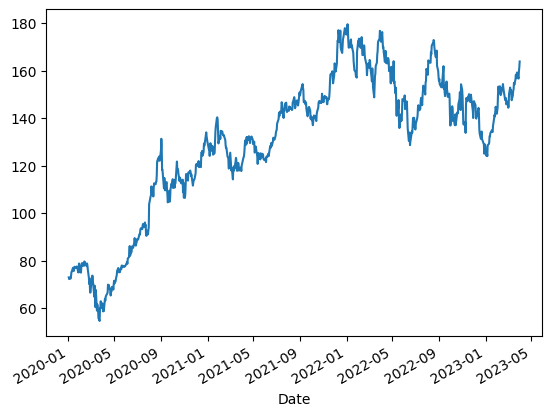

In [27]:
# Graficar precio de cierre ajustado
df['Adj Close'].plot();

# Datos 1D - Pandas Series

La principal ventaja de las series de Pandas frente a los arreglos en Numpy es que no está limitado a ser del mismo tipo de dato. En Numpy todos los elementos deben ser del mismo tipo de estructura de dato (cadenas, enteros, booleanos, etc). Las series de Pandas son muy flexibles y no sufren de esta limitación.

In [28]:
lista1 = [1, 2, 3]
lista2 = [4, 5, 6]
index_list = ["idx1", "idx2", "idx3"]

In [29]:
# Crear Serie1 a partir de lista1
serie1 = pd.Series(data=lista1)
serie1

0    1
1    2
2    3
dtype: int64

In [30]:
# Crear Serie2 a partir de lista2
serie2 = pd.Series(data=lista2)
serie2

0    4
1    5
2    6
dtype: int64

In [31]:
# Suma con índices iguales
serie3 = serie1 + serie2
serie3

0    5
1    7
2    9
dtype: int64

In [32]:
# Crear serie agregando índice y nombre
serie1 = pd.Series(data=lista1, name='col1', index=index_list)
serie1

idx1    1
idx2    2
idx3    3
Name: col1, dtype: int64

In [33]:
# Suma con índices diferentes
serie3 = serie1 + serie2
serie3

idx1   NaN
idx2   NaN
idx3   NaN
0      NaN
1      NaN
2      NaN
dtype: float64

In [34]:
serie1

idx1    1
idx2    2
idx3    3
Name: col1, dtype: int64

In [35]:
# Seleccionar valores dentro de Pandas Series (1)
serie1['idx2']

2

In [36]:
# Seleccionar valores dentro de pandas Series (2)
serie1['idx2':]

idx2    2
idx3    3
Name: col1, dtype: int64

In [37]:
# Acceder al nombre
serie1.name

'col1'

In [38]:
# Acceder a valores únicos
serie1.unique()

array([1, 2, 3])

# Datos 2D - Pandas DataFrame

Un DataFrame en Pandas es una estrcutura de datos bidimensional que tiene etiquetas para sus filas y columnas. Los DataFrames son muy similares a las hojas de cálculo de Excel o Google Sheet.

In [39]:
# Crear DataFrame a partir de Pandas Series (1)
serie1.to_frame()

,col1
idx1,1
idx2,2
idx3,3


In [40]:
# Crear DataFrame a partir de Pandas Series (2)
df = pd.DataFrame(serie1)
df.head()

,col1
idx1,1
idx2,2
idx3,3


In [41]:
# Crear DataFrame a partir de un diccionario
dict1 = {
    'A' : [1, 2, 3],
    'B' : [4, 5, 6],
    'C' : [7, 8, 9]
}
df = pd.DataFrame(dict1)
df.head()

,A,B,C
0,1,4,7
1,2,5,8
2,3,6,9


In [42]:
# Crear DataFrame a partir de lista de diccionarios
lista_dict = [
    {'A': 1, 'B': 4, 'C': 7},
    {'A': 2, 'B': 5, 'C': 8}
]
df = pd.DataFrame(lista_dict)
df.head()

,A,B,C
0,1,4,7
1,2,5,8


In [43]:
# Crear DataFrame a partir de diccionario de diccionarios
dict_dict = {
    'col1' : {'idx1': 1, 'idx2': 4, 'idx3': 7},
    'col2' : {'idx1': 2, 'idx2': 5, 'idx3': 8}
}
df = pd.DataFrame(dict_dict)
df.head()

,col1,col2
idx1,1,2
idx2,4,5
idx3,7,8


In [44]:
# Acceder a una columna
df['col1']

idx1    1
idx2    4
idx3    7
Name: col1, dtype: int64

In [45]:
# Checar tipo de variable
print(type(df))
print(type(df['col1']))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


In [46]:
# Leer columnas
df.columns

Index(['col1', 'col2'], dtype='object')

In [47]:
# Leer índices
df.index

Index(['idx1', 'idx2', 'idx3'], dtype='object')

In [48]:
# Leer valores como arreglo de Numpy
df.values

array([[1, 2],
       [4, 5],
       [7, 8]])

In [49]:
# Crear una nueva columna
df['new_col'] = [3, 6, 9]
df

,col1,col2,new_col
idx1,1,2,3
idx2,4,5,6
idx3,7,8,9


In [50]:
# Crear una nueva columna con método "assign"
df = df.assign(new_column_2 = df['col1'] * 3)
df

,col1,col2,new_col,new_column_2
idx1,1,2,3,3
idx2,4,5,6,12
idx3,7,8,9,21


In [51]:
# Matriz transpuesta: Cambiar fila por columnas
df.T

,idx1,idx2,idx3
col1,1,4,7
col2,2,5,8
new_col,3,6,9
new_column_2,3,12,21


In [52]:
# Renombrar a los índices
df.index = ['i1', 'i2', 'i3']
df

,col1,col2,new_col,new_column_2
i1,1,2,3,3
i2,4,5,6,12
i3,7,8,9,21


In [53]:
# Renombrar columnas
df.columns = ['colA', 'colB', 'colC', 'colD']
df

,colA,colB,colC,colD
i1,1,2,3,3
i2,4,5,6,12
i3,7,8,9,21


In [54]:
# Crear DataFrame con fechas como índices
idx = pd.date_range(dt.datetime(2020,2,1), periods=6, freq='M') # M=Final del mes
data = {
    'revenue' : [10, 34, 72, 34, 39, 98 ]
}
df = pd.DataFrame(data, index=idx)
df.head()

,revenue
2020-02-29,10
2020-03-31,34
2020-04-30,72
2020-05-31,34
2020-06-30,39


# Datos con múltiples dimensiones

In [55]:
# Ejemplo de múltiples dimensiones. Leer "APPLE (AAPL)"
start = dt.datetime(2020,1,1)
end = dt.datetime(2020,12,31)
df = yf.download(['MSFT', 'AAPL'], start, end)
df.head()

[*********************100%%**********************]  2 of 2 completed


Price       Adj Close                  Close                   High  \
Ticker           AAPL        MSFT       AAPL        MSFT       AAPL   
Date                                                                  
2020-01-02  72.960457  154.215668  75.087502  160.619995  75.150002   
2020-01-03  72.251144  152.295395  74.357498  158.619995  75.144997   
2020-01-06  72.826843  152.689072  74.949997  159.029999  74.989998   
2020-01-07  72.484352  151.296890  74.597504  157.580002  75.224998   
2020-01-08  73.650330  153.706772  75.797501  160.089996  76.110001   

Price                         Low                   Open              \
Ticker            MSFT       AAPL        MSFT       AAPL        MSFT   
Date                                                                   
2020-01-02  160.729996  73.797501  158.330002  74.059998  158.779999   
2020-01-03  159.949997  74.125000  158.059998  74.287498  158.320007   
2020-01-06  159.100006  73.187500  156.509995  73.447502  157.080002   
2020-01-07  159.669998  74.370003  157.320007  74.959999  159.320007   
2020-01-08  160.800003  74.290001  157.949997  74.290001  158.929993   

Price          Volume            
Ticker           AAPL      MSFT  
Date                             
2020-01-02  135480400  22622100  
2020-01-03  146322800  21116200  
2020-01-06  118387200  20813700  
2020-01-07  108872000  21634100  
2020-01-08  132079200  27746500

In [56]:
# Leer columnas (observar múltiples dimensiones)
df.columns

MultiIndex([('Adj Close', 'AAPL'),
            ('Adj Close', 'MSFT'),
            (    'Close', 'AAPL'),
            (    'Close', 'MSFT'),
            (     'High', 'AAPL'),
            (     'High', 'MSFT'),
            (      'Low', 'AAPL'),
            (      'Low', 'MSFT'),
            (     'Open', 'AAPL'),
            (     'Open', 'MSFT'),
            (   'Volume', 'AAPL'),
            (   'Volume', 'MSFT')],
           names=['Price', 'Ticker'])

In [57]:
# Acceder a elementos
df['Adj Close']['MSFT']

Date
2020-01-02    154.215668
2020-01-03    152.295395
2020-01-06    152.689072
2020-01-07    151.296890
2020-01-08    153.706772
                 ...    
2020-12-23    214.455399
2020-12-24    216.134003
2020-12-28    218.278427
2020-12-29    217.492416
2020-12-30    215.095810
Name: MSFT, Length: 252, dtype: float64

# Seleccionar valores dentro de un DataFrame

In [58]:
# Leer archivo
filename = 'bank.csv'
df = pd.read_csv(filename, sep=';')
df.head(5) # mostrar los primeros 3

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [59]:
# Seleccionar solamente los valores como arreglo de Numpy
df.values

array([[30, 'unemployed', 'married', ..., 0, 'unknown', 'no'],
       [33, 'services', 'married', ..., 4, 'failure', 'no'],
       [35, 'management', 'single', ..., 1, 'failure', 'no'],
       ...,
       [57, 'technician', 'married', ..., 0, 'unknown', 'no'],
       [28, 'blue-collar', 'married', ..., 3, 'other', 'no'],
       [44, 'entrepreneur', 'single', ..., 7, 'other', 'no']],
      dtype=object)

In [60]:
# Seleccionar los índices
df.index

RangeIndex(start=0, stop=4521, step=1)

In [61]:
# Seleccionar una columna
df['balance'] # o df.balance

0       1787
1       4789
2       1350
3       1476
4          0
        ... 
4516    -333
4517   -3313
4518     295
4519    1137
4520    1136
Name: balance, Length: 4521, dtype: int64

In [62]:
# Seleccionar una columna (como DataFrame)
df[['balance']].head()

,balance
0,1787
1,4789
2,1350
3,1476
4,0


In [63]:
# Seleccionar varias columnas
df[['age', 'balance']].head()

,age,balance
0,30,1787
1,33,4789
2,35,1350
3,30,1476
4,59,0


In [64]:
# Seleccionar filas por su posición en el índice
df.iloc[0]

age                  30
job          unemployed
marital         married
education       primary
default              no
balance            1787
housing              no
loan                 no
contact        cellular
day                  19
month               oct
duration             79
campaign              1
pdays                -1
previous              0
poutcome        unknown
y                    no
Name: 0, dtype: object

In [65]:
# Seleccionar filas como DataFrame por su posición en el índice
df.iloc[[0]] # df.iloc[0,:]

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no


In [66]:
# Seleccionar filas y columnas por su posición en el índice
df.iloc[0:3, 0:3]

,age,job,marital
0,30,unemployed,married
1,33,services,married
2,35,management,single


In [67]:
# Acceso rápido por su posición en el índice (usado para un solo valor)
df.iat[1, 0] # acceso rápido a un valor

33

In [68]:
# Seleccionar columnas por su índice (nombre)
df.loc[:, ['age', 'job']] # en este caso el nombre del índice es el mismo que su posición

,age,job
0,30,unemployed
1,33,services
2,35,management
3,30,management
4,59,blue-collar
...,...,...
4516,33,services
4517,57,self-employed
4518,57,technician
4519,28,blue-collar


In [69]:
# Seleccionar filas por su índice (nombre)
df.loc[0] # en este caso el nombre del índice es el mismo que su posición

age                  30
job          unemployed
marital         married
education       primary
default              no
balance            1787
housing              no
loan                 no
contact        cellular
day                  19
month               oct
duration             79
campaign              1
pdays                -1
previous              0
poutcome        unknown
y                    no
Name: 0, dtype: object

In [70]:
# Seleccionar filas y columnas por su índice (nombre)
df.loc[[0,1,4],['age', 'balance']]

,age,balance
0,30,1787
1,33,4789
4,59,0


In [71]:
# Acceso rápido por su índice (usado para un solo valor)
df.at[0, 'age']

30

## Filtrar datos

In [72]:
# Leer archivo
filename = 'bank.csv'
df = pd.read_csv(filename, sep=';')
df.head(5) # mostrar los primeros 3

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [73]:
# Aplicar filtros
df[df['balance']>30000]

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
2989,42,entrepreneur,married,tertiary,no,42045,no,no,cellular,8,aug,205,2,-1,0,unknown,no
3700,60,retired,married,primary,no,71188,no,no,cellular,6,oct,205,1,-1,0,unknown,no


In [74]:
# Aplicar filtros
df.query('balance > 30000')

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
2989,42,entrepreneur,married,tertiary,no,42045,no,no,cellular,8,aug,205,2,-1,0,unknown,no
3700,60,retired,married,primary,no,71188,no,no,cellular,6,oct,205,1,-1,0,unknown,no


In [75]:
# Crear máscara (filtro)
mask = df['balance']>30000
mask

0       False
1       False
2       False
3       False
4       False
        ...  
4516    False
4517    False
4518    False
4519    False
4520    False
Name: balance, Length: 4521, dtype: bool

In [76]:
# Aplicar máscara
df[mask]

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
2989,42,entrepreneur,married,tertiary,no,42045,no,no,cellular,8,aug,205,2,-1,0,unknown,no
3700,60,retired,married,primary,no,71188,no,no,cellular,6,oct,205,1,-1,0,unknown,no


In [77]:
# Aplicar filtros directamente
df[(df['balance']>30000) & (df['education'] == 'primary')]

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
3700,60,retired,married,primary,no,71188,no,no,cellular,6,oct,205,1,-1,0,unknown,no


In [78]:
# Filtrar evaluando si los valores en una columna se encuentran en una lista
job_list = ['unemployed', 'student', 'retired'] # Podemos ver la lista completa con df['job'].unique()

df[df['job'].isin(job_list)].head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
13,20,student,single,secondary,no,502,no,no,cellular,30,apr,261,1,-1,0,unknown,yes
27,67,retired,married,unknown,no,696,no,no,telephone,17,aug,119,1,105,2,failure,no
30,68,retired,divorced,secondary,no,4189,no,no,telephone,14,jul,897,2,-1,0,unknown,yes
36,78,retired,divorced,primary,no,229,no,no,telephone,22,oct,97,1,-1,0,unknown,yes


In [79]:
# Revisar los valores únicos en una columna
df['marital'].unique() # lo mismo que df.marital.unique()

array(['married', 'single', 'divorced'], dtype=object)

In [80]:
# Crear máscara que evalúe si los valores en una columna se encuentran en una lista
col_filter = ['single', 'divorced']
mask = df['marital'].isin(col_filter)
df[mask].head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
5,35,management,single,tertiary,no,747,no,no,cellular,23,feb,141,2,176,3,failure,no
13,20,student,single,secondary,no,502,no,no,cellular,30,apr,261,1,-1,0,unknown,yes
17,37,admin.,single,tertiary,no,2317,yes,no,cellular,20,apr,114,1,152,2,failure,no
18,25,blue-collar,single,primary,no,-221,yes,no,unknown,23,may,250,1,-1,0,unknown,no


In [81]:
# Seleccionar el inverso de la máscara / filtro
df[~mask]

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
6,36,self-employed,married,tertiary,no,307,yes,no,cellular,14,may,341,1,330,2,other,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4514,38,blue-collar,married,secondary,no,1205,yes,no,cellular,20,apr,45,4,153,1,failure,no
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,jul,329,5,-1,0,unknown,no
4517,57,self-employed,married,tertiary,yes,-3313,yes,yes,unknown,9,may,153,1,-1,0,unknown,no
4518,57,technician,married,secondary,no,295,no,no,cellular,19,aug,151,11,-1,0,unknown,no


In [82]:
# Valores únicos de columna "marital"
df['marital'].unique()

array(['married', 'single', 'divorced'], dtype=object)

In [83]:
# Revisar los valores únicos de marital que no están en la máscara
df[~mask]['marital'].unique()

array(['married'], dtype=object)

# Funciones de agregación

In [84]:
# Funciones de agregación
df['balance'].sum() # count, sum, mean, median ...

6431836

In [85]:
# Podemos usar otras funciones
df['balance'].agg(np.sum)

6431836

In [86]:
df['balance'].head()

0    1787
1    4789
2    1350
3    1476
4       0
Name: balance, dtype: int64

In [87]:
# Suma acumulativa
df['balance'].cumsum() # cummax(), cummin() cumprod()

0          1787
1          6576
2          7926
3          9402
4          9402
         ...   
4516    6432581
4517    6429268
4518    6429563
4519    6430700
4520    6431836
Name: balance, Length: 4521, dtype: int64

In [88]:
repr(1234)[-1:]

'4'

In [89]:
# Función personalizada que sume los últimos dos dígitos
def custom_sum(series, last_digits):
    cum_sum = 0
    for x in series[:3]:
        cum_sum += int(repr(x)[-last_digits:])
    return cum_sum

# Podemos definir una función
df['balance'].agg(lambda x: custom_sum(x, 2)) # 87 + 89 + 50

226

# Manipular series y DataFrames

In [90]:
filename = 'bank.csv'
df = pd.read_csv(filename, sep=';')
df.head(3) # mostrar los primeros 3

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no


In [91]:
# Crear nuevas columnas
df['new_num'] = df['day'] + df['duration']
df['new_str'] = df['job'] + df['marital']
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,new_num,new_str
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no,98,unemployedmarried
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no,231,servicesmarried
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no,201,managementsingle
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no,202,managementmarried
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no,231,blue-collarmarried


In [92]:
# Leer columnas
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y', 'new_num', 'new_str'],
      dtype='object')

In [93]:
# Leer índice
df.index

RangeIndex(start=0, stop=4521, step=1)

In [94]:
# Reemplazar índice
df.set_index(df.index + 1).head() # inplace=True

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,new_num,new_str
1,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no,98,unemployedmarried
2,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no,231,servicesmarried
3,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no,201,managementsingle
4,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no,202,managementmarried
5,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no,231,blue-collarmarried


In [95]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,new_num,new_str
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no,98,unemployedmarried
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no,231,servicesmarried
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no,201,managementsingle
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no,202,managementmarried
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no,231,blue-collarmarried


In [96]:
# Eliminar columnas
df.drop(columns=['job','marital']).head() # inplace=True

,age,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,new_num,new_str
0,30,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no,98,unemployedmarried
1,33,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no,231,servicesmarried
2,35,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no,201,managementsingle
3,30,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no,202,managementmarried
4,59,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no,231,blue-collarmarried


In [97]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,new_num,new_str
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no,98,unemployedmarried
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no,231,servicesmarried
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no,201,managementsingle
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no,202,managementmarried
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no,231,blue-collarmarried


In [98]:
# Ordenar valores por una columna
df.sort_values('balance', ascending=False).head() # inplace=True

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,new_num,new_str
3700,60,retired,married,primary,no,71188,no,no,cellular,6,oct,205,1,-1,0,unknown,no,211,retiredmarried
2989,42,entrepreneur,married,tertiary,no,42045,no,no,cellular,8,aug,205,2,-1,0,unknown,no,213,entrepreneurmarried
1483,43,technician,single,tertiary,no,27733,yes,no,unknown,3,jun,164,7,-1,0,unknown,no,167,techniciansingle
1881,36,management,married,tertiary,no,27359,yes,no,unknown,3,jun,71,2,-1,0,unknown,no,74,managementmarried
3830,57,technician,married,tertiary,no,27069,no,yes,unknown,20,jun,174,3,-1,0,unknown,no,194,technicianmarried


In [99]:
# Ordenar valores por varias columnas
df.sort_values(['job', 'month']).head() # inplace=True

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,new_num,new_str
11,43,admin.,married,secondary,no,264,yes,no,cellular,17,apr,113,2,-1,0,unknown,no,130,admin.married
17,37,admin.,single,tertiary,no,2317,yes,no,cellular,20,apr,114,1,152,2,failure,no,134,admin.single
88,38,admin.,married,secondary,no,424,yes,no,cellular,17,apr,279,1,-1,0,unknown,no,296,admin.married
172,40,admin.,single,secondary,no,462,yes,yes,cellular,6,apr,272,1,335,4,other,no,278,admin.single
358,48,admin.,divorced,secondary,no,4099,no,no,cellular,2,apr,397,2,-1,0,unknown,yes,399,admin.divorced


In [100]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,new_num,new_str
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no,98,unemployedmarried
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no,231,servicesmarried
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no,201,managementsingle
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no,202,managementmarried
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no,231,blue-collarmarried


# Gráficos en Pandas

In [101]:
# Leer archivo de excel
filename = 'examples.xlsx'
df = pd.read_excel(filename, sheet_name='plots')
df.head()

,EmpID,Region,Gender,Age,Level,Sales
0,EMP01,Americas,M,25,1,19.2
1,EMP02,Europe,F,44,4,36.0
2,EMP03,Americas,M,29,2,24.0
3,EMP04,Latam,M,51,5,35.0
4,EMP05,Latam,F,34,3,29.6


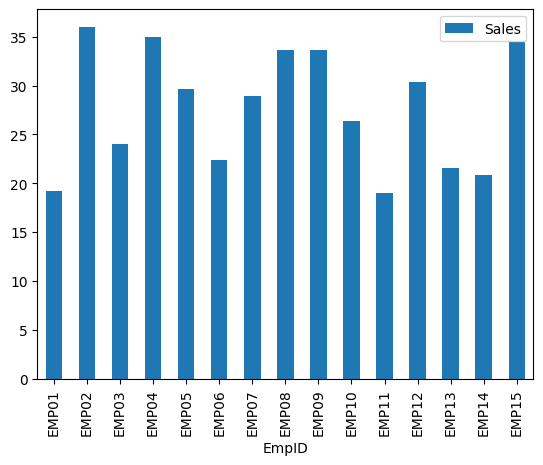

In [102]:
# Gráfico de barras
df.plot.bar(x='EmpID', y='Sales');

In [103]:
# Agrupar
df_region = df.groupby('Region').size()
df_region

Region
Americas    5
Asia        3
Europe      4
Latam       3
dtype: int64

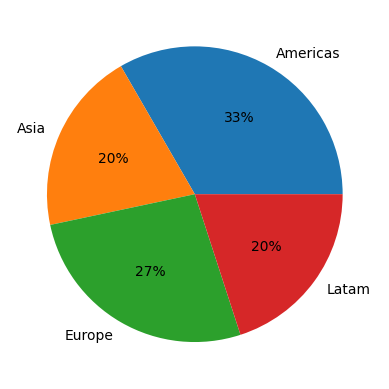

In [104]:
# Gráfico de círculo / pastel
df_region.plot.pie(autopct='%1.0f%%');

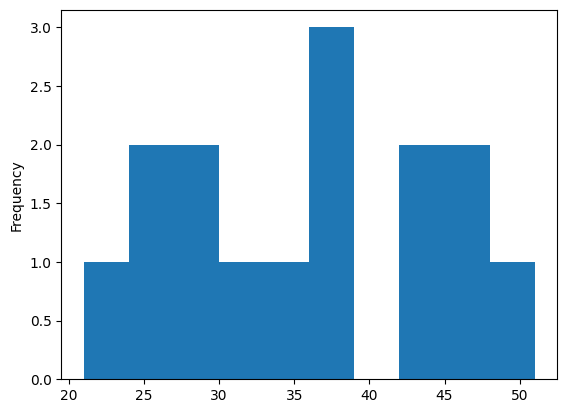

In [105]:
# Gráfico de histograma
df['Age'].plot.hist(); # bins=5

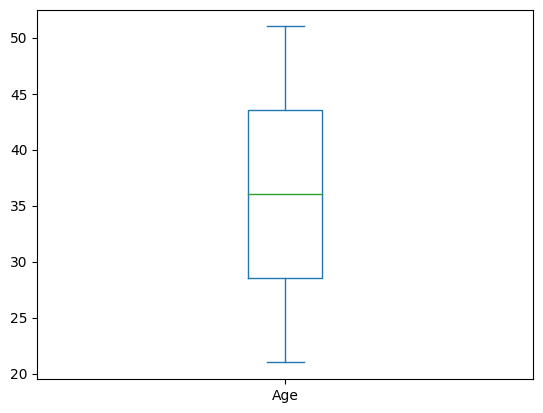

In [106]:
# Gráfico de cajas y bigotes
df['Age'].plot.box();

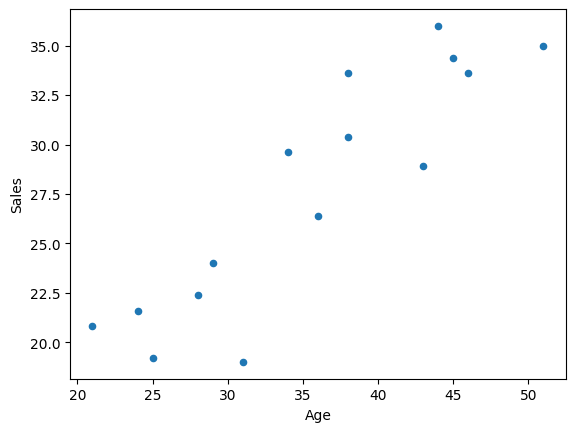

In [107]:
# Gráfico de dispersión
df.plot.scatter('Age', 'Sales');

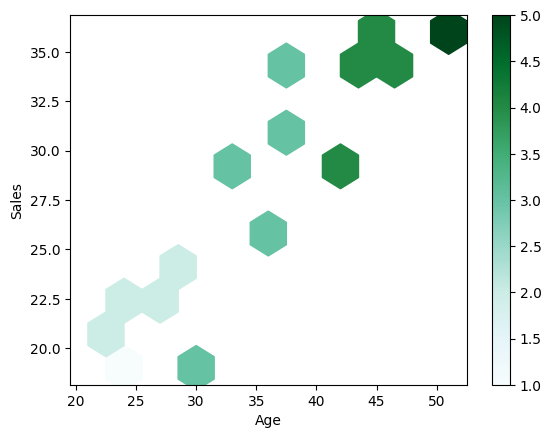

In [108]:
# Gráfico de dispersión con hexágonos
df.plot.hexbin('Age', 'Sales', 'Level', gridsize=10, sharex=False);

In [109]:
# Panda data reader stock market "APPLE (AAPL)"
start = dt.datetime(2020,1,1)
end = dt.datetime(2023,4,1)
# df = web.DataReader('AAPL', 'yahoo', start, end)
df = yf.download("AAPL", start, end)

[*********************100%%**********************]  1 of 1 completed


In [110]:
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2020-01-02,74.059998,75.150002,73.797501,75.087502,72.960487,135480400
2020-01-03,74.287498,75.144997,74.125000,74.357498,72.251129,146322800
2020-01-06,73.447502,74.989998,73.187500,74.949997,72.826851,118387200
2020-01-07,74.959999,75.224998,74.370003,74.597504,72.484360,108872000
2020-01-08,74.290001,76.110001,74.290001,75.797501,73.650352,132079200


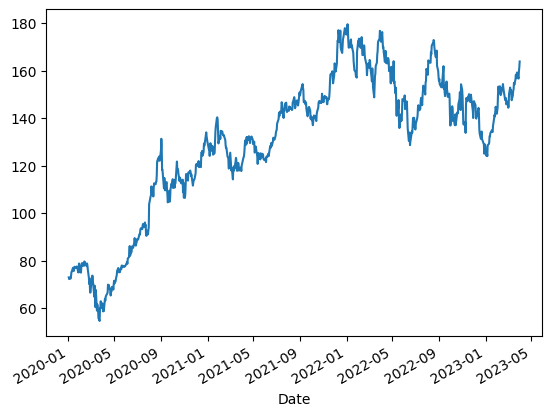

In [111]:
# Gráfico de líneas
df['Adj Close'].plot.line(); # o plot() as line is the default

In [112]:
# Panda data reader stock market "APPLE (AAPL) y Microsoft (MSFT)"
start = dt.datetime(2020,1,1)
end = dt.datetime(2023,4,1)
tickers = ['MSFT', 'AAPL']
df = yf.download(tickers, start, end)

[*********************100%%**********************]  2 of 2 completed


In [113]:
df.head()

Price       Adj Close                  Close                   High  \
Ticker           AAPL        MSFT       AAPL        MSFT       AAPL   
Date                                                                  
2020-01-02  72.960487  154.215637  75.087502  160.619995  75.150002   
2020-01-03  72.251129  152.295380  74.357498  158.619995  75.144997   
2020-01-06  72.826851  152.689072  74.949997  159.029999  74.989998   
2020-01-07  72.484360  151.296875  74.597504  157.580002  75.224998   
2020-01-08  73.650352  153.706818  75.797501  160.089996  76.110001   

Price                         Low                   Open              \
Ticker            MSFT       AAPL        MSFT       AAPL        MSFT   
Date                                                                   
2020-01-02  160.729996  73.797501  158.330002  74.059998  158.779999   
2020-01-03  159.949997  74.125000  158.059998  74.287498  158.320007   
2020-01-06  159.100006  73.187500  156.509995  73.447502  157.080002   
2020-01-07  159.669998  74.370003  157.320007  74.959999  159.320007   
2020-01-08  160.800003  74.290001  157.949997  74.290001  158.929993   

Price          Volume            
Ticker           AAPL      MSFT  
Date                             
2020-01-02  135480400  22622100  
2020-01-03  146322800  21116200  
2020-01-06  118387200  20813700  
2020-01-07  108872000  21634100  
2020-01-08  132079200  27746500

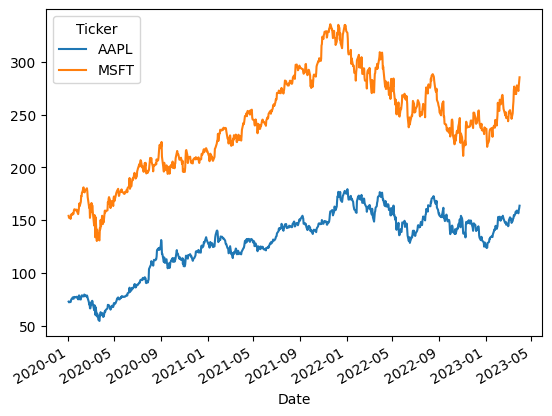

In [114]:
# Gráfico de múltiples líneas
df['Adj Close'].plot();

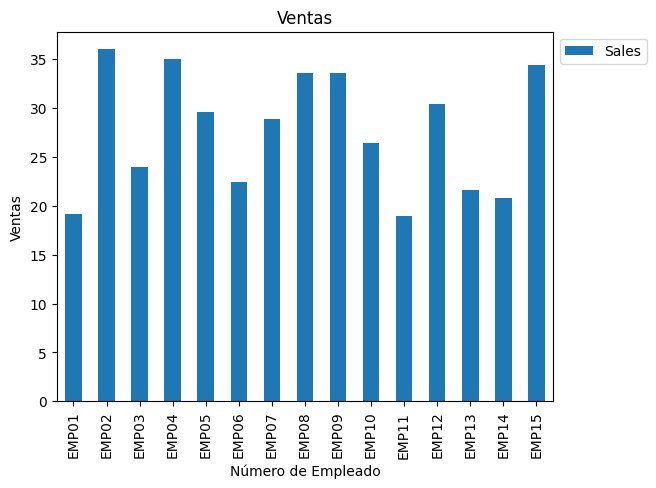

In [115]:
# Agregar detalles a gráfico

df = pd.read_excel('examples.xlsx', sheet_name='plots')
df.head()

df.plot.bar(x='EmpID', y='Sales',
            title='Ventas',
            xlabel='Número de Empleado',
            ylabel='Ventas').\
            legend(bbox_to_anchor=(1,1), loc='upper left');

# Métodos y atributos importantes

https://pandas.pydata.org/docs/reference/general_functions.html
https://pandas.pydata.org/docs/reference/series.html
https://pandas.pydata.org/docs/reference/frame.html

In [116]:
# Leer archivo CSV
filename = 'bank.csv'
df = pd.read_csv(filename, sep=';')
df.head(3) # mostrar los primeros 3

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no


In [117]:
# Leer índices
df.index

RangeIndex(start=0, stop=4521, step=1)

In [118]:
# Leer columnas
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [119]:
# Leer valores como arreglo de Numpy
df.values

array([[30, 'unemployed', 'married', ..., 0, 'unknown', 'no'],
       [33, 'services', 'married', ..., 4, 'failure', 'no'],
       [35, 'management', 'single', ..., 1, 'failure', 'no'],
       ...,
       [57, 'technician', 'married', ..., 0, 'unknown', 'no'],
       [28, 'blue-collar', 'married', ..., 3, 'other', 'no'],
       [44, 'entrepreneur', 'single', ..., 7, 'other', 'no']],
      dtype=object)

In [120]:
# Leer forma del DataFrame
df.shape

(4521, 17)

In [121]:
# Leer información
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


In [122]:
# Leer los tipos de datos de las columnas del DataFrame
df.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

In [123]:
df.convert_dtypes() # Convierte los datos al mejor tipo de dato posible,
# En este caso están bien los datos

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,jul,329,5,-1,0,unknown,no
4517,57,self-employed,married,tertiary,yes,-3313,yes,yes,unknown,9,may,153,1,-1,0,unknown,no
4518,57,technician,married,secondary,no,295,no,no,cellular,19,aug,151,11,-1,0,unknown,no
4519,28,blue-collar,married,secondary,no,1137,no,no,cellular,6,feb,129,4,211,3,other,no


In [124]:
# Longitud de DataFrame (número de registros)
len(df)

4521

In [125]:
# Tipo de dato
type(df)

pandas.core.frame.DataFrame

In [126]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [127]:
df.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,jul,329,5,-1,0,unknown,no
4517,57,self-employed,married,tertiary,yes,-3313,yes,yes,unknown,9,may,153,1,-1,0,unknown,no
4518,57,technician,married,secondary,no,295,no,no,cellular,19,aug,151,11,-1,0,unknown,no
4519,28,blue-collar,married,secondary,no,1137,no,no,cellular,6,feb,129,4,211,3,other,no
4520,44,entrepreneur,single,tertiary,no,1136,yes,yes,cellular,3,apr,345,2,249,7,other,no


In [128]:
# Revisar si los valores del índice son únicos
df.index.is_unique

True

In [129]:
# Revisar si los valores de una columna son únicos
df['education'].is_unique

False

In [130]:
# Obtener valores únicos de una columna
df['education'].unique()

array(['primary', 'secondary', 'tertiary', 'unknown'], dtype=object)

In [131]:
# Descripción de valores numéricos
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


In [132]:
# Describir valores no númericos
df.describe(exclude=np.number) # include='object' para no numéricos o include='all' para mostrar todos

,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,4521,4521,4521,4521,4521,4521,4521,4521,4521,4521
unique,12,3,4,2,2,2,3,12,4,2
top,management,married,secondary,no,yes,no,cellular,may,unknown,no
freq,969,2797,2306,4445,2559,3830,2896,1398,3705,4000


In [133]:
# Describir una variable numérica
df['age'].describe()

count    4521.000000
mean       41.170095
std        10.576211
min        19.000000
25%        33.000000
50%        39.000000
75%        49.000000
max        87.000000
Name: age, dtype: float64

In [134]:
# Describir una variable categorica
df['marital'].describe()

count        4521
unique          3
top       married
freq         2797
Name: marital, dtype: object

In [135]:
# Copiar DataFrame
df2 = df.copy()
df2.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [136]:
# Contar valores
df['job'].value_counts()

job
management       969
blue-collar      946
technician       768
admin.           478
services         417
retired          230
self-employed    183
entrepreneur     168
unemployed       128
housemaid        112
student           84
unknown           38
Name: count, dtype: int64

In [137]:
# Valores únicos
df['job'].unique()

array(['unemployed', 'services', 'management', 'blue-collar',
       'self-employed', 'technician', 'entrepreneur', 'admin.', 'student',
       'housemaid', 'retired', 'unknown'], dtype=object)

## Reemplazar valores

In [138]:
filename = 'bank.csv'
df = pd.read_csv(filename, sep=';')
df.head(3) # mostrar los primeros 3

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no


In [139]:
# Seleccionar variables categóricas
df.select_dtypes('object').head()

,job,marital,education,default,housing,loan,contact,month,poutcome,y
0,unemployed,married,primary,no,no,no,cellular,oct,unknown,no
1,services,married,secondary,no,yes,yes,cellular,may,failure,no
2,management,single,tertiary,no,yes,no,cellular,apr,failure,no
3,management,married,tertiary,no,yes,yes,unknown,jun,unknown,no
4,blue-collar,married,secondary,no,yes,no,unknown,may,unknown,no


In [140]:
# Valores únicos
df['y'].unique()

array(['no', 'yes'], dtype=object)

In [141]:
# Reemplazar valores
housing_dict = {'no': 0, 'yes': 1}
df['y'] = df['y'].replace(housing_dict)
df['y'].unique()

array([0, 1])

## Apply

In [142]:
# Crear DataFrame
df = pd.DataFrame([[4, 9]] * 3, columns=['A', 'B'])
df

,A,B
0,4,9
1,4,9
2,4,9


In [143]:
# Aplicar funcion a cada variable/columna
df.apply(np.sqrt)

,A,B
0,2.0,3.0
1,2.0,3.0
2,2.0,3.0


In [144]:
df

,A,B
0,4,9
1,4,9
2,4,9


In [145]:
df.apply(lambda x: x + 1)

,A,B
0,5,10
1,5,10
2,5,10


In [146]:
df

,A,B
0,4,9
1,4,9
2,4,9


In [147]:
# Trabajar con una sola columna. La función apply aplicaría a cada fila
df['A'].apply(lambda x: x * 2)

0    8
1    8
2    8
Name: A, dtype: int64

In [148]:
# Leer archivo csv
df = pd.read_csv('bank.csv', sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [149]:
# Leer columnas
df.select_dtypes('object').columns

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'y'],
      dtype='object')

In [150]:
# Conteo de valores únicos
df['marital'].value_counts()

marital
married     2797
single      1196
divorced     528
Name: count, dtype: int64

In [151]:
# Lista de variables categóricas y frecuencia de sus categorías
df.select_dtypes('object').apply(lambda x: x.value_counts().to_dict())

job          {'management': 969, 'blue-collar': 946, 'techn...
marital      {'married': 2797, 'single': 1196, 'divorced': ...
education    {'secondary': 2306, 'tertiary': 1350, 'primary...
default                                {'no': 4445, 'yes': 76}
housing                              {'yes': 2559, 'no': 1962}
loan                                  {'no': 3830, 'yes': 691}
contact      {'cellular': 2896, 'unknown': 1324, 'telephone...
month        {'may': 1398, 'jul': 706, 'aug': 633, 'jun': 5...
poutcome     {'unknown': 3705, 'failure': 490, 'other': 197...
y                                     {'no': 4000, 'yes': 521}
dtype: object

# Agrupar valores

In [152]:
# Leer archivo de excel
filename = 'examples.xlsx'
df = pd.read_excel(filename, sheet_name='plots')
df.head()

,EmpID,Region,Gender,Age,Level,Sales
0,EMP01,Americas,M,25,1,19.2
1,EMP02,Europe,F,44,4,36.0
2,EMP03,Americas,M,29,2,24.0
3,EMP04,Latam,M,51,5,35.0
4,EMP05,Latam,F,34,3,29.6


In [153]:
# Agrupar valores por región
df_region = df.groupby('Region')
df_region

In [154]:
# Describir grupo
df_region.describe()

Age                                                      Level  \
         count       mean       std   min    25%   50%    75%   max count   
Region                                                                      
Americas   5.0  27.400000  6.580274  21.0  24.00  25.0  29.00  38.0   5.0   
Asia       3.0  38.333333  7.505553  31.0  34.50  38.0  42.00  46.0   3.0   
Europe     4.0  40.000000  8.041559  28.0  39.25  43.5  44.25  45.0   4.0   
Latam      3.0  40.333333  9.291573  34.0  35.00  36.0  43.50  51.0   3.0   

                    ...           Sales                                     \
              mean  ...  75%  max count       mean       std   min     25%   
Region              ...                                                      
Americas  2.000000  ...  2.0  3.0   5.0  23.840000  5.724334  19.2  20.800   
Asia      3.333333  ...  3.5  4.0   3.0  27.666667  7.674199  19.0  24.700   
Europe    3.500000  ...  4.0  4.0   4.0  30.425000  6.153793  22.4  27.275   
Latam     3.666667  ...  4.0  5.0   3.0  30.333333  4.346646  26.4  28.000   

                             
            50%   75%   max  
Region                       
Americas  21.60  24.0  33.6  
Asia      30.40  32.0  33.6  
Europe    31.65  34.8  36.0  
Latam     29.60  32.3  35.0  

[4 rows x 24 columns]

In [155]:
# Agrupar por la media
df_region = df.groupby('Region', as_index=False).mean(numeric_only=True) # numeric_only=True es necesario a partir de pandas 2.0
df_region

,Region,Age,Level,Sales
0,Americas,27.400000,2.000000,23.840000
1,Asia,38.333333,3.333333,27.666667
2,Europe,40.000000,3.500000,30.425000
3,Latam,40.333333,3.666667,30.333333


In [156]:
# Matriz transpuesta del DataFrame
df_region.set_index('Region').T

Region,Americas,Asia,Europe,Latam
Age,27.40,38.333333,40.000,40.333333
Level,2.00,3.333333,3.500,3.666667
Sales,23.84,27.666667,30.425,30.333333


In [157]:
# Agrupar por región
df_region = df.groupby('Region')
df_region

In [158]:
# Tamaño de los grupos
df_region.size()

Region
Americas    5
Asia        3
Europe      4
Latam       3
dtype: int64

In [159]:
# Es lo mismo que contar los valores únicos
df['Region'].value_counts()

Region
Americas    5
Europe      4
Latam       3
Asia        3
Name: count, dtype: int64

In [160]:
df

,EmpID,Region,Gender,Age,Level,Sales
0,EMP01,Americas,M,25,1,19.2
1,EMP02,Europe,F,44,4,36.0
2,EMP03,Americas,M,29,2,24.0
3,EMP04,Latam,M,51,5,35.0
4,EMP05,Latam,F,34,3,29.6
5,EMP06,Europe,M,28,2,22.4
6,EMP07,Europe,F,43,4,28.9
7,EMP08,Asia,M,46,4,33.6
8,EMP09,Americas,M,38,3,33.6
9,EMP10,Latam,F,36,3,26.4


In [161]:
# Aplicar función de agregación (suma)
df_region.sum()

,EmpID,Gender,Age,Level,Sales
Region,,,,,
Americas,EMP01EMP03EMP09EMP13EMP14,MMMFF,137,10,119.2
Asia,EMP08EMP11EMP12,MMF,115,10,83.0
Europe,EMP02EMP06EMP07EMP15,FMFM,160,14,121.7
Latam,EMP04EMP05EMP10,MFF,121,11,91.0


In [162]:
# Aplicar función de agregación (media)
df_region.mean(numeric_only=True) # numeric_only=True es necesario a partir de Pandas 2.0

,Age,Level,Sales
Region,,,
Americas,27.400000,2.000000,23.840000
Asia,38.333333,3.333333,27.666667
Europe,40.000000,3.500000,30.425000
Latam,40.333333,3.666667,30.333333


In [163]:
# Definir función de agregación
df_region.agg(sum)

,EmpID,Gender,Age,Level,Sales
Region,,,,,
Americas,EMP01EMP03EMP09EMP13EMP14,MMMFF,137,10,119.2
Asia,EMP08EMP11EMP12,MMF,115,10,83.0
Europe,EMP02EMP06EMP07EMP15,FMFM,160,14,121.7
Latam,EMP04EMP05EMP10,MFF,121,11,91.0


In [164]:
print(df_region.dtypes)


           EmpID  Region  Gender    Age  Level    Sales
Region                                                 
Americas  object  object  object  int64  int64  float64
Asia      object  object  object  int64  int64  float64
Europe    object  object  object  int64  int64  float64
Latam     object  object  object  int64  int64  float64


In [165]:
# Agregar por varias funciones
# df_region.agg([np.mean, np.median, np.sum]) # Esto no funciona a partir de Pandas 2.0.

# Una opción es seleccionar las columnas numéricas cuando agrupamos
# Aquí seleccionamos las columnas numéricas + la columna en la que vamos a agrupar "Region"

selected_columns = ['Region'] + df.select_dtypes(include=[np.number]).columns.to_list()
df_region_numeric = df[selected_columns].groupby('Region')
df_region_numeric.agg([np.mean, np.median, np.sum]) # <== Aquí ya funciona

Age                 Level                 Sales              
               mean median  sum      mean median sum       mean median    sum
Region                                                                       
Americas  27.400000   25.0  137  2.000000    2.0  10  23.840000  21.60  119.2
Asia      38.333333   38.0  115  3.333333    3.0  10  27.666667  30.40   83.0
Europe    40.000000   43.5  160  3.500000    4.0  14  30.425000  31.65  121.7
Latam     40.333333   36.0  121  3.666667    3.0  11  30.333333  29.60   91.0

## Agrupar con tablas pivote

In [166]:
# Leer excel
filename = 'examples.xlsx'
df = pd.read_excel(filename, sheet_name='plots')
df.head()

,EmpID,Region,Gender,Age,Level,Sales
0,EMP01,Americas,M,25,1,19.2
1,EMP02,Europe,F,44,4,36.0
2,EMP03,Americas,M,29,2,24.0
3,EMP04,Latam,M,51,5,35.0
4,EMP05,Latam,F,34,3,29.6


In [167]:
# Tabla pivote simple
df.pivot_table(values='Age', index='Gender', aggfunc=np.mean)

,Age
Gender,
F,34.285714
M,36.625000


In [168]:
# Diferentes funciones de agregación
agg = [np.sum, np.mean, np.median]
df.pivot_table(values='Age', index='Gender', aggfunc=agg)

,sum,mean,median
,Age,Age,Age
Gender,,,
F,240,34.285714,36.0
M,293,36.625000,34.5


In [169]:
# En dos variables
df.pivot_table(values='Age', index='Gender', columns='Region')

Region,Americas,Asia,Europe,Latam
Gender,,,,
F,22.500000,38.0,43.5,35.0
M,30.666667,38.5,36.5,51.0


In [170]:
df.pivot_table(values='Age', index='Gender', columns='Region', fill_value=0) # Agregar valor para valores nulos

Region,Americas,Asia,Europe,Latam
Gender,,,,
F,22.500000,38.0,43.5,35
M,30.666667,38.5,36.5,51


# Manejo de valores faltantes

In [171]:
# Leer archivo de excel
filename = 'examples.xlsx'
df = pd.read_excel(filename, sheet_name='missing-data')
df.head(10)

,EmpID,Region,Gender,Age,Level,Sales
0,EMP01,Americas,M,25.0,1,19.2
1,EMP02,Europe,F,NaN,4,NaN
2,EMP03,Americas,M,29.0,2,24.0
3,EMP04,Latam,M,51.0,5,35.0
4,EMP05,Latam,F,34.0,3,29.6
5,EMP06,Europe,M,28.0,2,22.4
6,EMP07,Europe,F,43.0,4,28.9
7,EMP08,Asia,M,46.0,4,NaN
8,EMP09,Americas,M,NaN,3,33.6
9,EMP10,Latam,F,36.0,3,26.4


In [172]:
# Revisar si existen valores nulos en las variables
df.isnull().any()

EmpID     False
Region    False
Gender    False
Age        True
Level     False
Sales      True
dtype: bool

In [173]:
# Formato
pd.set_option('display.max_columns', None)

df.style.highlight_null()

,EmpID,Region,Gender,Age,Level,Sales
0,EMP01,Americas,M,25.000000,1,19.200000
1,EMP02,Europe,F,nan,4,nan
2,EMP03,Americas,M,29.000000,2,24.000000
3,EMP04,Latam,M,51.000000,5,35.000000
4,EMP05,Latam,F,34.000000,3,29.600000
5,EMP06,Europe,M,28.000000,2,22.400000
6,EMP07,Europe,F,43.000000,4,28.900000
7,EMP08,Asia,M,46.000000,4,nan
8,EMP09,Americas,M,nan,3,33.600000
9,EMP10,Latam,F,36.000000,3,26.400000


In [174]:
# Eliminar valores nulos
df.dropna()

,EmpID,Region,Gender,Age,Level,Sales
0,EMP01,Americas,M,25.0,1,19.2
2,EMP03,Americas,M,29.0,2,24.0
3,EMP04,Latam,M,51.0,5,35.0
4,EMP05,Latam,F,34.0,3,29.6
5,EMP06,Europe,M,28.0,2,22.4
6,EMP07,Europe,F,43.0,4,28.9
9,EMP10,Latam,F,36.0,3,26.4
10,EMP11,Asia,M,31.0,3,19.0
12,EMP13,Americas,F,24.0,2,21.6
13,EMP14,Americas,F,21.0,2,20.8


In [175]:
# Volver a leer el archivo de excel
filename = 'examples.xlsx'
df = pd.read_excel(filename, sheet_name='missing-data')
df

,EmpID,Region,Gender,Age,Level,Sales
0,EMP01,Americas,M,25.0,1,19.2
1,EMP02,Europe,F,NaN,4,NaN
2,EMP03,Americas,M,29.0,2,24.0
3,EMP04,Latam,M,51.0,5,35.0
4,EMP05,Latam,F,34.0,3,29.6
5,EMP06,Europe,M,28.0,2,22.4
6,EMP07,Europe,F,43.0,4,28.9
7,EMP08,Asia,M,46.0,4,NaN
8,EMP09,Americas,M,NaN,3,33.6
9,EMP10,Latam,F,36.0,3,26.4


In [176]:
# Imputar / reemplazar valores nulos
df.fillna(value=100000)

,EmpID,Region,Gender,Age,Level,Sales
0,EMP01,Americas,M,25.0,1,19.2
1,EMP02,Europe,F,100000.0,4,100000.0
2,EMP03,Americas,M,29.0,2,24.0
3,EMP04,Latam,M,51.0,5,35.0
4,EMP05,Latam,F,34.0,3,29.6
5,EMP06,Europe,M,28.0,2,22.4
6,EMP07,Europe,F,43.0,4,28.9
7,EMP08,Asia,M,46.0,4,100000.0
8,EMP09,Americas,M,100000.0,3,33.6
9,EMP10,Latam,F,36.0,3,26.4


In [177]:
# Volver a leer el archivo de excel
filename = 'examples.xlsx'
df = pd.read_excel(filename, sheet_name='missing-data')
df

,EmpID,Region,Gender,Age,Level,Sales
0,EMP01,Americas,M,25.0,1,19.2
1,EMP02,Europe,F,NaN,4,NaN
2,EMP03,Americas,M,29.0,2,24.0
3,EMP04,Latam,M,51.0,5,35.0
4,EMP05,Latam,F,34.0,3,29.6
5,EMP06,Europe,M,28.0,2,22.4
6,EMP07,Europe,F,43.0,4,28.9
7,EMP08,Asia,M,46.0,4,NaN
8,EMP09,Americas,M,NaN,3,33.6
9,EMP10,Latam,F,36.0,3,26.4


In [178]:
# Reemplazar valores nulos con una función, p.ej. media
df.fillna(df.mean(numeric_only=True).astype(int)) # numeric_only=True es necesario a partir de Pandas 2.0

,EmpID,Region,Gender,Age,Level,Sales
0,EMP01,Americas,M,25.0,1,19.2
1,EMP02,Europe,F,34.0,4,26.0
2,EMP03,Americas,M,29.0,2,24.0
3,EMP04,Latam,M,51.0,5,35.0
4,EMP05,Latam,F,34.0,3,29.6
5,EMP06,Europe,M,28.0,2,22.4
6,EMP07,Europe,F,43.0,4,28.9
7,EMP08,Asia,M,46.0,4,26.0
8,EMP09,Americas,M,34.0,3,33.6
9,EMP10,Latam,F,36.0,3,26.4


In [179]:
df.mean(numeric_only=True).astype(int) # numeric_only=True es necesario a partir de Pandas 2.0

Age      34
Level     3
Sales    26
dtype: int64

# Valores duplicados

In [180]:
df = pd.DataFrame({
    'brand': ['Yum Yum', 'Yum Yum', 'Indomie', 'Indomie', 'Indomie'],
    'style': ['cup', 'cup', 'cup', 'pack', 'pack'],
    'rating': [4, 4, 3.5, 15, 5]
})

In [181]:
df

,brand,style,rating
0,Yum Yum,cup,4.0
1,Yum Yum,cup,4.0
2,Indomie,cup,3.5
3,Indomie,pack,15.0
4,Indomie,pack,5.0


In [182]:
# Revisar número de registros duplicados
df.duplicated().sum()

1

In [183]:
# Revisar registros duplicados
df.duplicated()

0    False
1     True
2    False
3    False
4    False
dtype: bool

In [184]:
# Mantener el primer valor de los valores duplicados
df.duplicated(keep='first')

0    False
1     True
2    False
3    False
4    False
dtype: bool

In [185]:
# Mantener el último valor de los valores duplicados
df.duplicated(keep='last')

0     True
1    False
2    False
3    False
4    False
dtype: bool

In [186]:
df

,brand,style,rating
0,Yum Yum,cup,4.0
1,Yum Yum,cup,4.0
2,Indomie,cup,3.5
3,Indomie,pack,15.0
4,Indomie,pack,5.0


In [187]:
# Revisar valores duplicados en un subconjunto del DataFrame
df.duplicated(subset=['brand'])

0    False
1     True
2    False
3     True
4     True
dtype: bool

In [188]:
# Eliminar los registros duplicados
df.drop_duplicates()
# df = df.drop_duplicates()
# df.drop_duplicates(inplace=True)

,brand,style,rating
0,Yum Yum,cup,4.0
2,Indomie,cup,3.5
3,Indomie,pack,15.0
4,Indomie,pack,5.0


In [189]:
df

,brand,style,rating
0,Yum Yum,cup,4.0
1,Yum Yum,cup,4.0
2,Indomie,cup,3.5
3,Indomie,pack,15.0
4,Indomie,pack,5.0


In [190]:
# Eliminar valores duplicados de un subconjunto y manteniendo solamente el último registro duplicado
df.drop_duplicates(subset=['brand', 'style'], keep='last')

,brand,style,rating
1,Yum Yum,cup,4.0
2,Indomie,cup,3.5
4,Indomie,pack,5.0


# Combinar DataFrames

## Concat

Fuente: https://pandas.pydata.org/pandas-docs/stable/user_guide/merging.html

<img src="https://pandas.pydata.org/pandas-docs/stable/_images/merging_concat_basic.png" alt="" >

In [191]:
df1 = pd.DataFrame(
    {
        "A": ["A0", "A1", "A2", "A3"],
        "B": ["B0", "B1", "B2", "B3"],
        "C": ["C0", "C1", "C2", "C3"],
        "D": ["D0", "D1", "D2", "D3"],
    },
    index=[0, 1, 2, 3],
)

df2 = pd.DataFrame(
    {
        "A": ["A4", "A5", "A6", "A7"],
        "B": ["B4", "B5", "B6", "B7"],
        "C": ["C4", "C5", "C6", "C7"],
        "D": ["D4", "D5", "D6", "D7"],
    },
    index=[4, 5, 6, 7],
)

df3 = pd.DataFrame(
    {
        "A": ["A8", "A9", "A10", "A11"],
        "B": ["B8", "B9", "B10", "B11"],
        "C": ["C8", "C9", "C10", "C11"],
        "D": ["D8", "D9", "D10", "D11"],
    },
    index=[8, 9, 10, 11],
)

In [192]:
df1

,A,B,C,D
0,A0,B0,C0,D0
1,A1,B1,C1,D1
2,A2,B2,C2,D2
3,A3,B3,C3,D3


In [193]:
df2

,A,B,C,D
4,A4,B4,C4,D4
5,A5,B5,C5,D5
6,A6,B6,C6,D6
7,A7,B7,C7,D7


In [194]:
# Concatenar DataFrames
frames = [df1, df2, df3]
result = pd.concat(frames)
result

,A,B,C,D
0,A0,B0,C0,D0
1,A1,B1,C1,D1
2,A2,B2,C2,D2
3,A3,B3,C3,D3
4,A4,B4,C4,D4
5,A5,B5,C5,D5
6,A6,B6,C6,D6
7,A7,B7,C7,D7
8,A8,B8,C8,D8
9,A9,B9,C9,D9


In [195]:
# Concatenar y agregar claves (índice) a cada DataFrame
result = pd.concat(frames, keys=['df1', 'df2', 'df3'])
result

A    B    C    D
df1 0    A0   B0   C0   D0
    1    A1   B1   C1   D1
    2    A2   B2   C2   D2
    3    A3   B3   C3   D3
df2 4    A4   B4   C4   D4
    5    A5   B5   C5   D5
    6    A6   B6   C6   D6
    7    A7   B7   C7   D7
df3 8    A8   B8   C8   D8
    9    A9   B9   C9   D9
    10  A10  B10  C10  D10
    11  A11  B11  C11  D11

In [196]:
# Revisar índices (multi-índice)
result.index

MultiIndex([('df1',  0),
            ('df1',  1),
            ('df1',  2),
            ('df1',  3),
            ('df2',  4),
            ('df2',  5),
            ('df2',  6),
            ('df2',  7),
            ('df3',  8),
            ('df3',  9),
            ('df3', 10),
            ('df3', 11)],
           )

In [197]:
# Acceder al primer DataFrame df1 a través del índice
result.loc['df1']

,A,B,C,D
0,A0,B0,C0,D0
1,A1,B1,C1,D1
2,A2,B2,C2,D2
3,A3,B3,C3,D3


## Append

In [198]:
df1 = pd.DataFrame(
    {
        "A": ["A0", "A1", "A2", "A3"],
        "B": ["B0", "B1", "B2", "B3"],
        "C": ["C0", "C1", "C2", "C3"],
        "D": ["D0", "D1", "D2", "D3"],
    },
    index=[0, 1, 2, 3],
)

df2 = pd.DataFrame(
    {
        "A": ["A4", "A5", "A6", "A7"],
        "B": ["B4", "B5", "B6", "B7"],
        "C": ["C4", "C5", "C6", "C7"],
        "D": ["D4", "D5", "D6", "D7"],
    },
    index=[4, 5, 6, 7],
)

df3 = pd.DataFrame(
    {
        "A": ["A8", "A9", "A10", "A11"],
        "B": ["B8", "B9", "B10", "B11"],
        "C": ["C8", "C9", "C10", "C11"],
        "D": ["D8", "D9", "D10", "D11"],
    },
    index=[8, 9, 10, 11],
)

In [199]:
# Agregar un DataFrame a otro DataFrame
# result = df1.append(df2) # append cambió a _append
result = df1._append(df2)
result

,A,B,C,D
0,A0,B0,C0,D0
1,A1,B1,C1,D1
2,A2,B2,C2,D2
3,A3,B3,C3,D3
4,A4,B4,C4,D4
5,A5,B5,C5,D5
6,A6,B6,C6,D6
7,A7,B7,C7,D7


## Merge

Fuente: https://pandas.pydata.org/pandas-docs/stable/user_guide/merging.html

<img src="https://pandas.pydata.org/pandas-docs/stable/_images/merging_merge_on_key.png">

In [200]:
df_left = pd.DataFrame(
    {
        "key": ["K0", "K1", "K2", "K3"],
        "A": ["A0", "A1", "A2", "A3"],
        "B": ["B0", "B1", "B2", "B3"],
    }
)


df_right = pd.DataFrame(
    {
        "key": ["K0", "K1", "K2", "K3"],
        "C": ["C0", "C1", "C2", "C3"],
        "D": ["D0", "D1", "D2", "D3"],
    }
)

In [201]:
# Combinar DataFrames
result = pd.merge(df_left, df_right, on="key")
result

,key,A,B,C,D
0,K0,A0,B0,C0,D0
1,K1,A1,B1,C1,D1
2,K2,A2,B2,C2,D2
3,K3,A3,B3,C3,D3


## Join

| Merge Method | SQL Join Name | Description |
| --- | --- | --- |
| left | LEFT OUTER JOIN | Use keys from left frame only |
| right | RIGHT OUTER JOIN | Use keys from right frame only
| outer | FULL OUTER JOIN | Use union of keys from both frames
| inner | INNER JOIN | Use intersection of keys from both frames

<p>
<img style='background-color:white' src="https://drive.google.com/uc?export=view&id=1zC74Yr-gIP-P_KRqF1YKlihYortbKP-c" width=700>


In [202]:
df_left = pd.DataFrame(
    {
        "key1": ["K0", "K0", "K1", "K2"],
        "key2": ["K0", "K1", "K0", "K1"],
        "A": ["A0", "A1", "A2", "A3"],
        "B": ["B0", "B1", "B2", "B3"],
    }
)


df_right = pd.DataFrame(
    {
        "key1": ["K0", "K1", "K1", "K2"],
        "key2": ["K0", "K0", "K0", "K0"],
        "C": ["C0", "C1", "C2", "C3"],
        "D": ["D0", "D1", "D2", "D3"],
    }
)

### Join Left

<img src="https://pandas.pydata.org/pandas-docs/stable/_images/merging_merge_on_key_left.png">
<p>
<img src="https://drive.google.com/uc?export=view&id=1V4tX6waEcsIqLUZH8mQFaRPx97FFWHQ7" width=350>

In [203]:
df_left

,key1,key2,A,B
0,K0,K0,A0,B0
1,K0,K1,A1,B1
2,K1,K0,A2,B2
3,K2,K1,A3,B3


In [204]:
df_right

,key1,key2,C,D
0,K0,K0,C0,D0
1,K1,K0,C1,D1
2,K1,K0,C2,D2
3,K2,K0,C3,D3


In [205]:
# Aplicar join left (unión a la izquierda)
result = pd.merge(df_left, df_right, how="left", on=["key1", "key2"])
result

,key1,key2,A,B,C,D
0,K0,K0,A0,B0,C0,D0
1,K0,K1,A1,B1,NaN,NaN
2,K1,K0,A2,B2,C1,D1
3,K1,K0,A2,B2,C2,D2
4,K2,K1,A3,B3,NaN,NaN


### Join Right

<img src="https://pandas.pydata.org/pandas-docs/stable/_images/merging_merge_on_key_right.png">
<p>
<img src="https://drive.google.com/uc?export=view&id=1ZU6XxfddV60mu-wLpv6w7zavrrcONH-3" width=350>

In [206]:
df_left

,key1,key2,A,B
0,K0,K0,A0,B0
1,K0,K1,A1,B1
2,K1,K0,A2,B2
3,K2,K1,A3,B3


In [207]:
df_right

,key1,key2,C,D
0,K0,K0,C0,D0
1,K1,K0,C1,D1
2,K1,K0,C2,D2
3,K2,K0,C3,D3


In [208]:
# Aplicar join right (unión a la derecha)
result = pd.merge(df_left, df_right, how="right", on=["key1", "key2"])
result

,key1,key2,A,B,C,D
0,K0,K0,A0,B0,C0,D0
1,K1,K0,A2,B2,C1,D1
2,K1,K0,A2,B2,C2,D2
3,K2,K0,NaN,NaN,C3,D3


### Join Outer

<img src="https://pandas.pydata.org/pandas-docs/stable/_images/merging_merge_on_key_outer.png">
<p>
<img src="https://drive.google.com/uc?export=view&id=1JMsF1SjX9Q-ur79Uwjgwj54btwtT8uAt" width=350>

In [209]:
df_left

,key1,key2,A,B
0,K0,K0,A0,B0
1,K0,K1,A1,B1
2,K1,K0,A2,B2
3,K2,K1,A3,B3


In [210]:
df_right

,key1,key2,C,D
0,K0,K0,C0,D0
1,K1,K0,C1,D1
2,K1,K0,C2,D2
3,K2,K0,C3,D3


In [211]:
# Aplicar outer join (unión exterior)
result = pd.merge(df_left, df_right, how="outer", on=["key1", "key2"])
result

,key1,key2,A,B,C,D
0,K0,K0,A0,B0,C0,D0
1,K0,K1,A1,B1,NaN,NaN
2,K1,K0,A2,B2,C1,D1
3,K1,K0,A2,B2,C2,D2
4,K2,K1,A3,B3,NaN,NaN
5,K2,K0,NaN,NaN,C3,D3


### Join Inner

<img src="https://pandas.pydata.org/pandas-docs/stable/_images/merging_merge_on_key_inner.png">
<p>
<img src="https://drive.google.com/uc?export=view&id=1raC5fOtZgVMyHSXVihUTNd2eXvS8WDZN" width=350>

In [212]:
df_left

,key1,key2,A,B
0,K0,K0,A0,B0
1,K0,K1,A1,B1
2,K1,K0,A2,B2
3,K2,K1,A3,B3


In [213]:
df_right

,key1,key2,C,D
0,K0,K0,C0,D0
1,K1,K0,C1,D1
2,K1,K0,C2,D2
3,K2,K0,C3,D3


In [214]:
# Aplicar inner join (unión interior)
result = pd.merge(df_left, df_right, how="inner", on=["key1", "key2"])
result

,key1,key2,A,B,C,D
0,K0,K0,A0,B0,C0,D0
1,K1,K0,A2,B2,C1,D1
2,K1,K0,A2,B2,C2,D2


# Reportes

In [215]:
import seaborn as sns
import pandas as pd
from ydata_profiling import ProfileReport

In [216]:
# Leer DataFrame "Titanic"
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [217]:
# Revisar el número de registros y columnas
df.shape

(891, 15)

In [218]:
# Describir estadísticamente las variables numéricas
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [219]:
# Describir las variables no numéricas
df.describe(include='object')

,sex,embarked,who,embark_town,alive
count,891,889,891,889,891
unique,2,3,3,3,2
top,male,S,man,Southampton,no
freq,577,644,537,644,549


In [220]:
# Matriz de correlación
df.corr(numeric_only=True) # mean(), cov()  # numeric_only=True es necesario a partir de Pandas 2.0

,survived,pclass,age,sibsp,parch,fare,adult_male,alone
survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307,-0.557080,-0.203367
pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500,0.094035,0.135207
age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067,0.280328,0.198270
sibsp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651,-0.253586,-0.584471
parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225,-0.349943,-0.583398
fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000,-0.182024,-0.271832
adult_male,-0.557080,0.094035,0.280328,-0.253586,-0.349943,-0.182024,1.000000,0.404744
alone,-0.203367,0.135207,0.198270,-0.584471,-0.583398,-0.271832,0.404744,1.000000


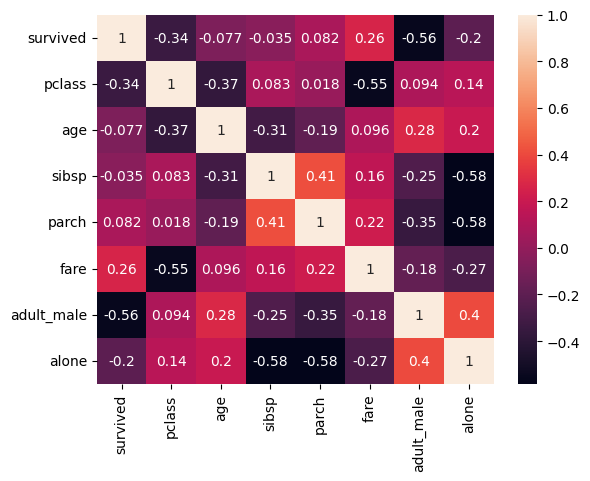

In [221]:
# Mapa de calor para matriz de correlación
sns.heatmap(df.corr(numeric_only=True), annot=True);

In [222]:
# Revisar valores faltantes
df.isnull().any()

survived       False
pclass         False
sex            False
age             True
sibsp          False
parch          False
fare           False
embarked        True
class          False
who            False
adult_male     False
deck            True
embark_town     True
alive          False
alone          False
dtype: bool

Text(0.5, 1.0, 'Valores faltantes')

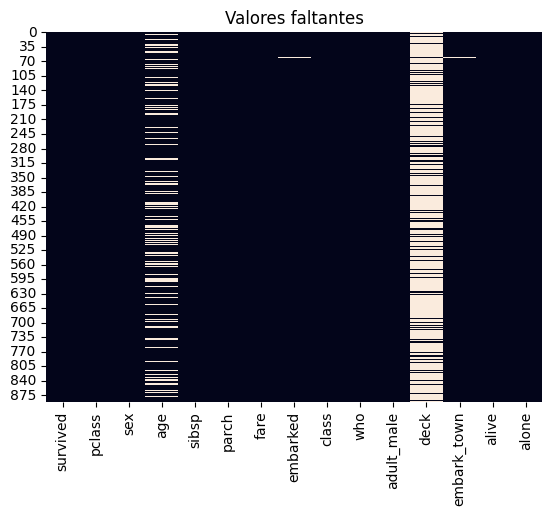

In [223]:
# Revisar valores faltantes (gráficamente)
sns.heatmap(df.isnull(), cbar = False).set_title("Valores faltantes")

In [224]:
# Generar reporte de perfil
report = ProfileReport(df.sample(n=300), title="Pandas Profiling Report")  # para muchos datos usar: df.sample(n=300)
report

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [225]:
# Guardar reporte en archivo HTML
report.to_file(output_file="reporte.html")

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# Entradas y salidas en Pandas

In [226]:
import numpy as np
import pandas as pd

In [227]:
# Crear DataFrame con datos aleatorios
data = np.random.rand(5,5)
columns = ['A', 'B', 'C', 'D', 'E']
df = pd.DataFrame(data=data, columns=columns)
df.head()

,A,B,C,D,E
0,0.011107,0.404717,0.338907,0.357962,0.177502
1,0.874278,0.433618,0.295598,0.067241,0.972566
2,0.005902,0.105028,0.902757,0.250031,0.335185
3,0.348713,0.306234,0.081847,0.022446,0.554718
4,0.648377,0.363484,0.713232,0.674109,0.292601


In [228]:
# Guardar DataFrame en portapapeles
# df.to_clipboard()

In [229]:
# Guardar DataFrame in CSV file
df.to_csv('name.csv')

In [230]:
# Guardar DataFrame in XLSX file
df.to_excel('name.xlsx')

# Conexión a bases de datos

In [231]:
# Crear conexión con SQLite
from sqlalchemy import create_engine, text

dbname = 'mydatabase.db' # Crear base de datos
engine = create_engine('sqlite:///' + dbname)

Otras conexiones: https://docs.sqlalchemy.org/en/14/core/engines.html
* PostgreSQL
* MySQL
* Oracle
* MSFT SQL Server
* SQLite
* Otros

In [232]:
# Crear DataFrame
df = pd.DataFrame({'name' : ['User 1', 'User 2', 'User 3']})
df

,name
0,User 1
1,User 2
2,User 3


In [233]:
# Crear nueva tabla
df.to_sql('users', con=engine, if_exists='replace')

3

In [234]:
# Usar SQL queries
query = "SELECT * FROM users"
with engine.connect() as conn:
  result = conn.execute(text(query)).fetchall() #engine.execute(query).fetchall() # sqlalchemy v1.4

print(result)

[(0, 'User 1'), (1, 'User 2'), (2, 'User 3')]


In [235]:
# https://levelup.gitconnected.com/how-to-fix-attributeerror-optionengine-object-has-no-attribute-execute-in-pandas-eb635fbb89e4
# Leer query con pandas

pd.read_sql_query(sql=text(query), con=engine.connect()) # pd.read_sql_query(query, con=engine) # sqlalchemy v1.4

,index,name
0,0,User 1
1,1,User 2
2,2,User 3


Descargar base de datos:
- https://www.sqlitetutorial.net/wp-content/uploads/2018/03/chinook.zip

<p>
<img src="https://drive.google.com/uc?export=view&id=1D7IRKwCuxdt-xn0DGqcKb_tCg35SDmQS" width=800>


Fuente: https://www.sqlitetutorial.net/wp-content/uploads/2018/03/sqlite-sample-database-diagram.pdf

In [236]:
# Conectarse a base de datos SQLite
dbname = 'chinook.db'
engine = create_engine('sqlite:///' + dbname)

In [237]:
# Leer tablas
query = '''
SELECT name FROM sqlite_master WHERE type='table'
'''
pd.read_sql_query(sql=text(query), con=engine.connect()) # pd.read_sql_query(query, con=engine) # old version 1.4

,name
0,albums
1,sqlite_sequence
2,artists
3,customers
4,employees
5,genres
6,invoices
7,invoice_items
8,media_types
9,playlists


In [238]:
# Leer tabla "customers"
query = '''
SELECT * FROM customers
'''
df = pd.read_sql_query(sql=text(query), con=engine.connect()) # df = pd.read_sql_query(query, con=engine) # sqlalchemy 1.4
df.head()

,CustomerId,FirstName,LastName,Company,Address,City,State,Country,PostalCode,Phone,Fax,Email,SupportRepId
0,1,Luís,Gonçalves,Embraer - Empresa Brasileira de Aeronáutica S.A.,"Av. Brigadeiro Faria Lima, 2170",São José dos Campos,SP,Brazil,12227-000,+55 (12) 3923-5555,+55 (12) 3923-5566,luisg@embraer.com.br,3
1,2,Leonie,Köhler,None,Theodor-Heuss-Straße 34,Stuttgart,None,Germany,70174,+49 0711 2842222,None,leonekohler@surfeu.de,5
2,3,François,Tremblay,None,1498 rue Bélanger,Montréal,QC,Canada,H2G 1A7,+1 (514) 721-4711,None,ftremblay@gmail.com,3
3,4,Bjørn,Hansen,None,Ullevålsveien 14,Oslo,None,Norway,0171,+47 22 44 22 22,None,bjorn.hansen@yahoo.no,4
4,5,František,Wichterlová,JetBrains s.r.o.,Klanova 9/506,Prague,None,Czech Republic,14700,+420 2 4172 5555,+420 2 4172 5555,frantisekw@jetbrains.com,4


In [239]:
# Obtener valores únicos
df['Country'].unique()

array(['Brazil', 'Germany', 'Canada', 'Norway', 'Czech Republic',
       'Austria', 'Belgium', 'Denmark', 'USA', 'Portugal', 'France',
       'Finland', 'Hungary', 'Ireland', 'Italy', 'Netherlands', 'Poland',
       'Spain', 'Sweden', 'United Kingdom', 'Australia', 'Argentina',
       'Chile', 'India'], dtype=object)

In [240]:
# Cerrar conexión
engine.dispose()

## Conectarse a MySQL / PostgreSQL

Instalar:
- !pip install SQLAlchemy
- !pip install MySQL-python
- !pip install psycopg2

Ejemplo de código:
```python
user = 'root' # Nombre de usuario
password = '******************' # Contraseña
dbname = 'db_name' # Nombre de base de datos
host = 'database.abcd.us-east-1.rds.amazonaws.com' # Servidor
port = '3306' # Puerto

dbengine = 'mysql://' # Para mysql
dbengine = 'postgresql+psycopg2://' # Para PostgreSQL

engine = create_engine(f'{dbengine}{user}:{password}@{host}:{port}/{dbname}')

df = pd.read_sql_query(sql=text(query), con=engine.connect())

df.head()
```